# Notebook to combine ACF real data and model simulations.
___

In [1]:
import sys; from pathlib import Path
src_dir = next(parent / 'src' for parent in Path().absolute().parents if (parent / 'src').is_dir())
sys.path.extend([str(src_dir), str(src_dir / 'pipelines')])
main_dir = Path(src_dir.parents[0])
from imports import * 
current_dir = Path().resolve() 
from microlive.imports import *
from microlive import microscopy as mi

In [2]:
# Modeling
from tasep_models import *

In [4]:
# Update rcParams to set a white background and Arial fonts.
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.linewidth': 1.5,
    'font.family': 'sans-serif',
    'font.sans-serif': 'Arial',
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'axes.labelcolor': 'black',
    'text.color': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'axes.edgecolor': 'black',
})


## Loading folders
___

In [ ]:
# Path to data

results_folder = Path ('/Users/nzlab-la/Desktop/utag_paper/optimization/results_ACF')
results_ACF_plots = current_dir.joinpath('ACF_plots')
results_ACF_plots.mkdir(parents=True, exist_ok=True)


## Parameters to calculate the ACF
____

In [6]:
step_size_in_sec = 5
start_lag = 0
remove_outliers = True
selected_field = 'spot_int_ch_0'  # spot_int_ch_0, psf_amplitude_ch_0, snr_ch_0,
downsample = False
downsampling_factor = 2
y_axes_min_max_list_values =  [-0.02, 0.1]
x_axes_min_max_list_values = [-0.5, 24.5]
MAD_THRESHOLD_FACTOR = 4

multi_tau=False
multi_tau_raw_points = 60
multi_tau_bins_per_stage = 16

# Model Parameters

In [7]:
# # Initial conditions
number_repetitions = 200
burnin_time = 2000
t_max = 400*5 #timePerturbationApplication + 25*60  # Maximum time
step_size_in_sec = 5 # 5
time_array = np.arange(0, t_max, step_size_in_sec)

In [8]:
# Function to extract ki and ke from param files
def extract_params(filename):
    df = pd.read_csv(results_folder / filename)
    ki_value = df[df['parameter'] == 'ki']['value'].iloc[0]
    ke_value = df[df['parameter'] == 'ke']['value'].iloc[0]
    return float(ke_value), float(ki_value)

# Extract parameters for each dataset
ke_utag, ki_utag = extract_params('optimized_params_utag.csv')
ke_utag_c_free, ki_utag_c_free = extract_params('optimized_params_utag_c_free.csv')
ke_suntag, ki_suntag = extract_params('optimized_params_suntag.csv')
ke_alfatag, ki_alfatag = extract_params('optimized_params_alfatag.csv')
# Update your parameter list with extracted values
param_fit_utag = [ke_utag, ki_utag, 'utag'] # ke, ki, utag
param_fit_utag_c_free = [ke_utag_c_free, ki_utag_c_free, 'utag_c_free'] # ke, ki, utag_c_free
param_fit_suntag = [ke_suntag, ki_suntag, 'suntag'] # ke, ki, suntag
param_fit_alfatag = [ke_alfatag, ki_alfatag, 'alfatag'] # ke, ki, alfatag
list_param_fit = [param_fit_utag, param_fit_utag_c_free, param_fit_suntag, param_fit_alfatag]


## Loading datasets
___

In [9]:
def dataset_selection(dataset,downsample=False):
    if downsample:
        downsample_str = '_downsampled'
    else:
        downsample_str = ''
    
    if dataset == 'utag':
        plot_name = 'utag' + downsample_str
        folder_with_files = results_folder.joinpath('df_ACF_utag'+downsample_str+'.csv')
        tag_sequence = tag_dict['U']
        dna_file_path = main_dir.joinpath( 'gene_sequences','utag_project','pNZ208(pUB-24xUTagFullLength-KDM5B-MS2).dna' )
    
    elif dataset == 'utag_c_free':
        plot_name = 'utag_c_free' + downsample_str
        folder_with_files = results_folder.joinpath('df_ACF_utag_c_free'+downsample_str+'.csv')
        tag_sequence = tag_dict['U']
        dna_file_path = main_dir.joinpath( 'gene_sequences','utag_project','pNZ208(pUB-24xUTagFullLength-KDM5B-MS2).dna' )
    
    elif dataset == 'suntag':
        folder_with_files = results_folder.joinpath('df_ACF_suntag'+downsample_str+'.csv')
        plot_name = 'suntag' + downsample_str
        tag_sequence = tag_dict['SUN']
        dna_file_path = main_dir.joinpath( 'gene_sequences','utag_project','pNZ266(pUB-24xGCN4-KDM5B-MS2).dna' )
    elif dataset == 'alfatag':
        plot_name = 'alfatag' + downsample_str
        folder_with_files = results_folder.joinpath('df_ACF_alfatag'+downsample_str+'.csv')
        tag_sequence = tag_dict['ALFA']
        dna_file_path = main_dir.joinpath( 'gene_sequences','utag_project','pNZ267 (pUB-24xALFAtag-KDM5B-MS2).dna' )
    
    # reading the gene sequence
    protein, rna, dna, indexes_tags, _, seq_record, graphic_features  = read_sequence(seq=dna_file_path, min_protein_length=50,TAG=[tag_sequence])
    gene_length = len(protein)+1 # adding 1 to account for the stop codon
    tag_positions_first_probe_vector = indexes_tags[0]
    # print processing dataset
    print('dataset: ', dataset)
    print('tag_positions_first_probe_vector', tag_positions_first_probe_vector)
    # print the length of the tag sequence
    print('tag_sequence_length', len(tag_positions_first_probe_vector))
    first_probe_position_vector = create_probe_vector(tag_positions_first_probe_vector, gene_length)
    dataframe_ACF = pd.read_csv(folder_with_files)
    data_mean_correlation = dataframe_ACF['mean_correlation'].values
    data_std_correlation = dataframe_ACF['std_correlation'].values
    data_lags = dataframe_ACF['lags'].values
    return data_mean_correlation,data_std_correlation,data_lags, plot_name, rna, first_probe_position_vector, gene_length


In [10]:
def plot_correlation_comparison(mean_correlation, std_correlation, lags,
                                mean_correlation_ssa=None, std_correlation_ssa=None, lags_ssa=None,  
                                plot_name='temp', start_lag=0, y_axes_min_max_list_values=None,
                                x_axes_min_max_list_values=None, show_legend=True, ke=None, ki=None,
                                color_sim='dimgray', color_exp='orangered'):



    # Create the figure and axes.
    fig, ax = plt.subplots(figsize=(6, 2.5), facecolor='white')

    # convert lags to min by dividing by 60
    
    lags = lags / 60
    if lags_ssa is not None:
        lags_ssa = lags_ssa / 60

    marker_size = 5

    # Automatically determine the maxlag
    maxlag = len(lags)
    maxlag_ssa = len(lags_ssa) if lags_ssa is not None else 0

    legend_label_exp = 'Experimental'
    legend_label_sim = 'Model fit'
    # Plot the experimental correlation (blue).
    ax.plot(lags[start_lag:maxlag], mean_correlation[start_lag:maxlag],
            'o-', color=color_exp, linewidth=1, label=legend_label_exp, markersize=marker_size)
    ax.fill_between(lags[start_lag:maxlag],
                    mean_correlation[start_lag:maxlag] - std_correlation[start_lag:maxlag],
                    mean_correlation[start_lag:maxlag] + std_correlation[start_lag:maxlag],
                    color=color_exp, alpha=0.1)

    if mean_correlation_ssa is not None:
        # Plot the simulation correlation (red).
        ax.plot(lags_ssa[start_lag:maxlag_ssa], mean_correlation_ssa[start_lag:maxlag_ssa],
                '-', color=color_sim, linewidth=4, label=legend_label_sim)
        ax.fill_between(lags_ssa[start_lag:maxlag_ssa],
                        mean_correlation_ssa[start_lag:maxlag_ssa] - std_correlation_ssa[start_lag:maxlag_ssa],
                        mean_correlation_ssa[start_lag:maxlag_ssa] + std_correlation_ssa[start_lag:maxlag_ssa],
                        color=color_sim, alpha=0.1)

    # Add a legend.
    if show_legend:
        ax.legend(loc='upper right', fontsize=12, frameon=False)

    # Set axis limits.
    if x_axes_min_max_list_values is not None:
        ax.set_xlim(x_axes_min_max_list_values[0], x_axes_min_max_list_values[1])

    if y_axes_min_max_list_values is not None:
        ax.set_ylim(y_axes_min_max_list_values[0], y_axes_min_max_list_values[1])

    # Set axis labels and title.
    ax.set_xlabel(r'$\tau (min)$', fontsize=18)
    ax.set_ylabel(r'$G(\tau)$', fontsize=18)
    # set tick lable sizes to 14
    ax.tick_params(axis='both', which='major', labelsize=16)

    # Customize spines
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.5)

    # ensure the ticks are interger
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    #ax.yaxis.set_major_locator(MaxNLocator(integer=True))

    # Ensure layout is tight and save figure
    plt.tight_layout()
    #plt.savefig('comparison_ACF_' + plot_name + '.png', dpi=600)
    plt.savefig(results_ACF_plots.joinpath('ACF_model_data_'+plot_name+'.png'), dpi=600)
    plt.savefig(results_ACF_plots.joinpath('ACF_model_data_'+plot_name+'.svg'), dpi=600)

    plt.show()

In [11]:
# 

In [12]:
def run_simulation(global_elongation_rate,ki, rna, first_probe_position_vector,burnin_time, gene_length, t_max, step_size_in_sec, number_repetitions, MAD_THRESHOLD_FACTOR,plot_name,save_parameters=False, downsample = False,downsampling_factor = 2, use_minutes_for_lags=False):
    ke = calculate_codon_elongation_rates (rna, global_elongation_rate=global_elongation_rate)
    ssa_array = simulate_TASEP_SSA(ki, ke, gene_length, t_max,
                                time_interval_in_seconds=step_size_in_sec,
                                number_repetitions=number_repetitions, 
                                first_probe_position_vector=first_probe_position_vector, 
                                burnin_time=burnin_time,
                                constant_elongation_rate=global_elongation_rate,
                                fast_output=True)[2]
    # Calculating the autocorrelation of the intensity signal
    mean_correlation_ssa, std_correlation_ssa, lags_ssa, correlations_array, dwell_time = mi.Correlation(primary_data=ssa_array,
                                                                                            max_lag=None, 
                                                                                            nan_handling='forward_fill',  #forward_fill, 'ignore'
                                                                                            shift_data=True,
                                                                                            return_full=False,
                                                                                            time_interval_between_frames_in_seconds=step_size_in_sec,
                                                                                            use_bootstrap=True,
                                                                                            show_plot=False,
                                                                                            start_lag=0,
                                                                                            fit_type='linear',
                                                                                            de_correlation_threshold=0.01,
                                                                                            correct_baseline=True,
                                                                                            use_linear_projection_for_lag_0=True,
                                                                                            save_plots=False,
                                                                                            use_global_mean= False,
                                                                                            remove_outliers = True,
                                                                                            MAD_THRESHOLD_FACTOR = MAD_THRESHOLD_FACTOR,
                                                                                            plot_individual_trajectories = False,
                                                                                            y_axes_min_max_list_values = None, #y_axes_min_max_list_values,
                                                                                            x_axes_min_max_list_values=None,
                                                                                            multi_tau=multi_tau,
                                                                                            multi_tau_raw_points = multi_tau_raw_points,
                                                                                            multi_tau_bins_per_stage = multi_tau_bins_per_stage,
                                                                                            plot_title=None).run()
    if downsample:
        mean_correlation_ssa = mean_correlation_ssa[::downsampling_factor]
        std_correlation_ssa = std_correlation_ssa[::downsampling_factor]
        lags_ssa = lags_ssa[::downsampling_factor]
    # optimized parameters
    if save_parameters:
        parameters = {'ki': ki, 'ke': global_elongation_rate, 't_max': t_max, 'step_size_in_sec': step_size_in_sec, 'number_repetitions': number_repetitions, 'MAD_THRESHOLD_FACTOR': MAD_THRESHOLD_FACTOR}    
        df_parameters = pd.DataFrame(parameters.items(), columns=['parameter', 'value'])
        #df_parameters.to_csv(results_folder.joinpath('param_sim_'+plot_name+'.csv'), index=False)
    return mean_correlation_ssa, std_correlation_ssa, lags_ssa

dataset  utag 

dataset:  utag
tag_positions_first_probe_vector [8, 24, 40, 56, 72, 88, 110, 126, 142, 158, 174, 190, 212, 228, 244, 260, 276, 292, 314, 330, 346, 362, 378, 394]
tag_sequence_length 24
ki_calculated 0.0312658227848101
ke_calculated 3.113924050632911
-----------------------------------------------------



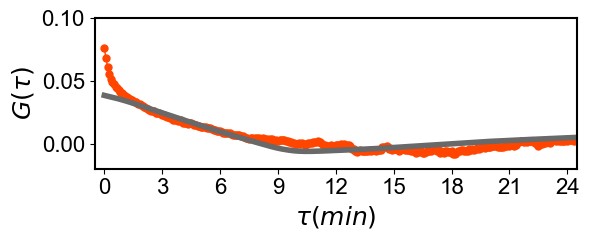

dataset  utag_c_free 

dataset:  utag_c_free
tag_positions_first_probe_vector [8, 24, 40, 56, 72, 88, 110, 126, 142, 158, 174, 190, 212, 228, 244, 260, 276, 292, 314, 330, 346, 362, 378, 394]
tag_sequence_length 24
ki_calculated 0.0631645569620253
ke_calculated 5.291139240506329
-----------------------------------------------------



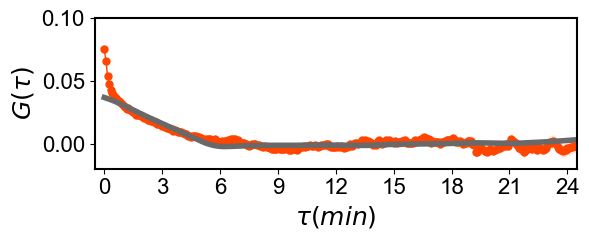

dataset  suntag 

dataset:  suntag
tag_positions_first_probe_vector [1, 25, 49, 73, 97, 121, 145, 169, 193, 217, 241, 265, 289, 313, 337, 361, 385, 409, 433, 457, 481, 505, 529, 553]
tag_sequence_length 24
ki_calculated 0.0339240506329113
ke_calculated 4.329113924050633
-----------------------------------------------------



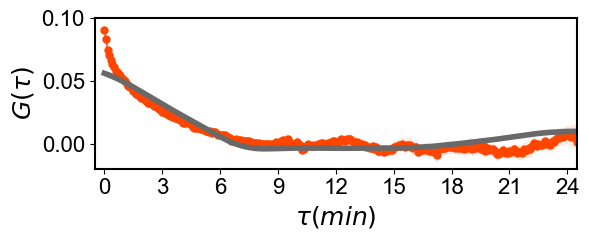

dataset  alfatag 

dataset:  alfatag
tag_positions_first_probe_vector [8, 26, 44, 62, 80, 98, 122, 140, 158, 176, 194, 212, 236, 254, 272, 290, 308, 326, 350, 368, 386, 404, 422, 440]
tag_sequence_length 24
ki_calculated 0.0427848101265822
ke_calculated 4.8354430379746836
-----------------------------------------------------



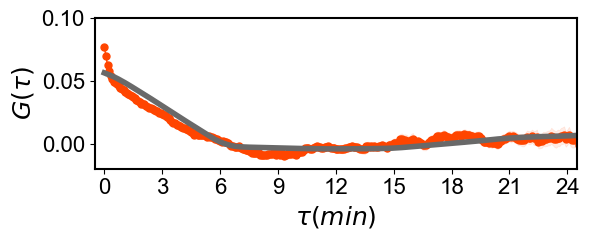

In [13]:
color_sim = 'dimgray'
color_exp = 'orangered'
for i, param_fit in enumerate(list_param_fit):
    print('dataset ', param_fit[2] , '\n')
    data_mean_correlation,data_std_correlation,data_lags, plot_name, rna, first_probe_position_vector, gene_length = dataset_selection (param_fit[2],downsample) #suntag 
    ki_calculated = param_fit[1] #1/(param_fit[1]*param_fit[0])
    print('ki_calculated', ki_calculated)
    ke_calculated = param_fit[0] #gene_length/(param_fit[0])
    print('ke_calculated', ke_calculated)
    print('-----------------------------------------------------\n')
    # setting the parameters
    ki = ki_calculated
    global_elongation_rate = ke_calculated
    # running the simulation
    mean_correlation_ssa, std_correlation_ssa, lags_ssa = run_simulation(global_elongation_rate,ki, rna, first_probe_position_vector, burnin_time, gene_length, t_max, step_size_in_sec, number_repetitions, MAD_THRESHOLD_FACTOR,plot_name,save_parameters=True,downsample = downsample,downsampling_factor =downsampling_factor)
    # Plotting the results
    plot_correlation_comparison(data_mean_correlation, data_std_correlation, data_lags,mean_correlation_ssa, std_correlation_ssa, lags_ssa, plot_name=plot_name, start_lag=start_lag, y_axes_min_max_list_values = y_axes_min_max_list_values,x_axes_min_max_list_values=x_axes_min_max_list_values,show_legend = False, ke=global_elongation_rate, ki=ki,color_sim=color_sim,color_exp=color_exp)
